In [ ]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys 

import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# load checkpoints
copy_unstruct = CheckPoint.from_pt("../models/batching_strategies/MLC_batchunstruct_dallstudy1copy_nep20.pt")
unstruct = CheckPoint.from_pt("../models/batching_strategies/MLC_batchunstruct_dallstudy1_nep20.pt")

In [20]:
# load models and dataset
model_copy = copy_unstruct.load_model()
model_unstruct = unstruct.load_model()
val = unstruct.load_dataloaders(data_dir=f"../{unstruct.train_config.dir_data}", val_batch_size=32, use_datasets=["val"])[0]

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 114,560
	best val loss achieved: 1.0794
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Loaded following dataloaders:
val dataloader (n=22,912)


In [21]:
batch = next(iter(val))

In [6]:
for i, n_perm in enumerate(batch["n_perm"]):
    if n_perm == 0:
        print(f"index {i}: {batch["transformation"][i]}")

index 34: rr_interleave
index 48: rr_sort
index 63: extend_group
index 107: sort_group
index 108: rr_interleave
index 118: shift
index 182: pred
index 185: rr_succ
index 188: extend_pred
index 191: extend_pred
index 208: fix_alphabetic_seq
index 212: replicate
index 221: sort
index 226: extend_sequence
index 283: sort_group
index 324: fix_alphabetic_seq
index 334: extend_group
index 338: shift
index 347: remove_redundant
index 358: sort_group
index 363: reverse
index 369: rr_interleave
index 374: extend_sequence
index 384: fix_interleave
index 400: rr_interleave
index 403: reverse
index 453: extend_extend_succ
index 472: rr_succ
index 477: sort_group
index 492: extend_sequence
index 500: rr_succ
index 504: sort_group
index 507: succ
index 511: remove_redundant
index 605: fix_alphabetic_seq
index 637: pred
index 646: replicate
index 655: reverse
index 659: replicate
index 665: shift
index 668: rr_succ
index 678: sort
index 706: rr_interleave
index 708: extend_sequence
index 716: fix_alp

### Attention Matrices per Layer

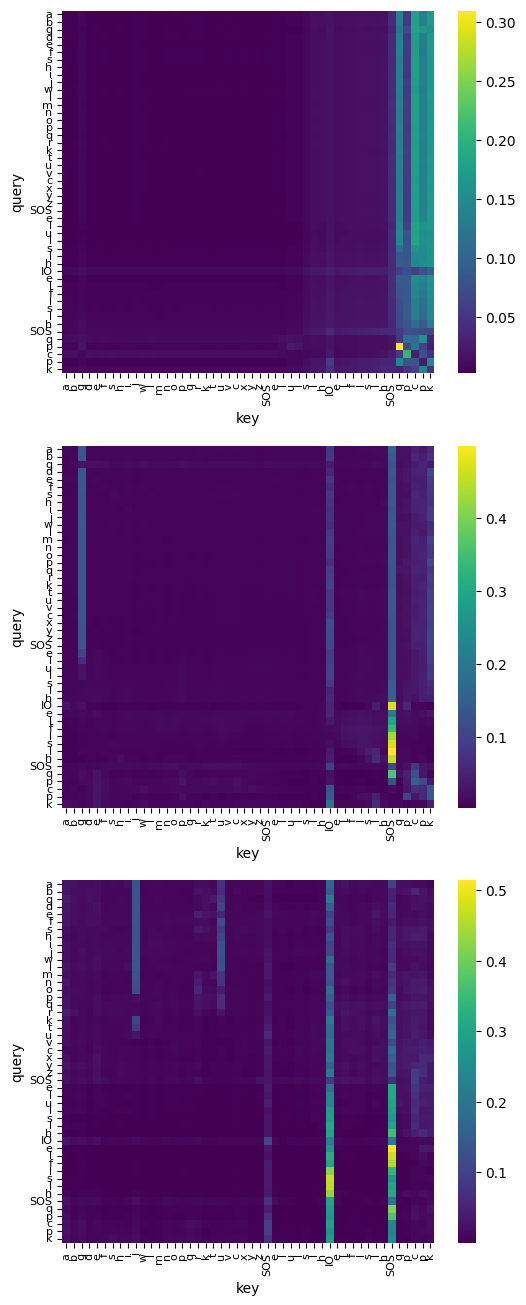

In [7]:
fig_noncopy, ax_noncopy = analysis_utils.get_encoder_attention_plot(model_unstruct, batch, idx=4264, titles=False)

In [8]:
fig_noncopy.savefig("../presentations/images/noncopy_encoder_attention.svg", format="svg")

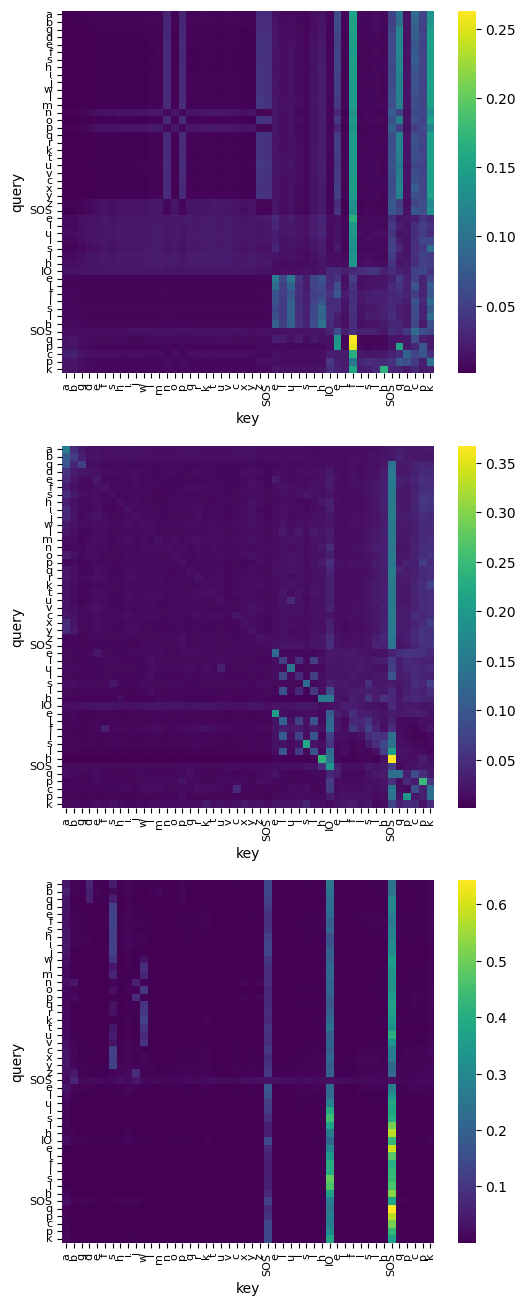

In [9]:
fig_copy, ax_copy = analysis_utils.get_encoder_attention_plot(model_copy, batch, idx=4264, titles=False)

In [10]:
# fig_copy.savefig("../presentations/images/copy_encoder_attention.svg", format="svg")

### Final Encoder Representations

In [14]:
model = copy_unstruct.load_model()
model.eval()

Loading model that has completed 21 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.7212
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


MLC(
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerDecoderLayer(
          (self_attn): MultiheadAttention(
          

In [25]:
src, src_key_padding_mask = model.prep_encode(batch['xq_context_padded'])
enc_representations = model.transformer.encoder.forward(
    src=src,
    src_key_padding_mask=src_key_padding_mask
)

In [26]:
enc_representations.shape

torch.Size([32, 93, 128])

In [126]:
D_val = LetterStringDataset(
    mode="val", 
    data_dir=f"../{unstruct.train_config.dir_data}", 
    batch_size=10,
    batching_method="transformation",
)
val = DataLoader(D_val, batch_sampler=D_val.sampler, collate_fn=D_val.collate_fn)

In [129]:
D_val.set_filter("transformation", ["pred"])
pred_batch = next(iter(val))
print(pred_batch["transformation"])

['pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred', 'pred']


In [128]:
D_val.set_filter("transformation", ["succ"])
succ_batch = next(iter(val))
print(succ_batch["transformation"])

['succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ', 'succ']


In [130]:
def get_encoder_representations(batch, model):
    src, src_key_padding_mask = model.prep_encode(batch['xq_context_padded'])
    # get encoder representations with shape (batch size, max context length batch, repr_dimension)
    enc_representations = model.transformer.encoder.forward(
        src=src,
        src_key_padding_mask=src_key_padding_mask
    )
    # reduce dimensions to shape (batch size, repr dimension):
    enc_representations = enc_representations.mean(dim=1)
    return enc_representations 

enc_repr_pred = get_encoder_representations(pred_batch, model)
enc_repr_succ = get_encoder_representations(succ_batch, model)

In [133]:
enc_repr_pred.shape

torch.Size([10, 128])

In [142]:
import torch.nn.functional as F

def get_cosine_similarity_matrix(a, b):
    """Concatenates two tensors along the first dimension and takes the cosine similarities for
    each element"""
    combined = torch.cat([a, b], dim=0)
    repr_norm = F.normalize(combined, p=2, dim=1)
    return repr_norm @ repr_norm.T

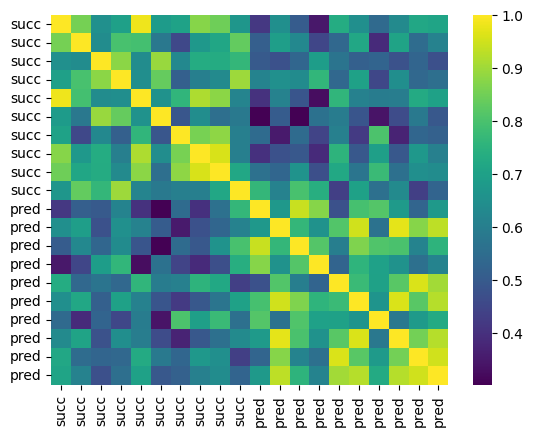

In [144]:
cosine_sim_matrix = get_cosine_similarity_matrix(enc_repr_pred, enc_repr_succ)

labels = succ_batch["transformation"] + pred_batch["transformation"]
_ = sns.heatmap(
    cosine_sim_matrix.detach().numpy(), 
    cmap="viridis", 
    xticklabels=labels, 
    yticklabels=labels
)

In [145]:
D_val.transformation_types

['fix_extend',
 'extend_group',
 'reverse',
 'sort',
 'rr_interleave',
 'succ',
 'extend_extend_succ',
 'fix_interleave',
 'rr_succ',
 'pred',
 'sort_group',
 'shift',
 'rr_sort',
 'fix_pred_succ',
 'remove_redundant',
 'extend_sequence',
 'extend_pred',
 'fix_alphabetic_seq',
 'replicate']

In [155]:
df = pd.DataFrame(copy_unstruct.val_acc_hist)
df[df["epoch"]==20]

,epoch,overall,copy,noncopy,extend_extend_succ,extend_group,extend_pred,extend_sequence,fix_alphabetic_seq,fix_extend,...,reverse,rr_interleave,rr_sort,rr_succ,shift,sort,sort_group,succ,in,out-of
19,20,0.629921,0.692063,0.567819,0.0,0.008483,0.012444,0.990894,0.72164,0.805533,...,0.0,0.998469,0.637213,0.986903,0.0,0.978534,0.970954,0.98568,0.943144,0.100352


### 2D Representation visualizations

In [147]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [169]:
D_val_unstruct = LetterStringDataset(
    mode="val", 
    data_dir=f"../{unstruct.train_config.dir_data}", 
    batch_size=22912
)
val_un = DataLoader(D_val_unstruct, batch_sampler=D_val_unstruct.sampler, collate_fn=D_val_unstruct.collate_fn)

In [170]:
all_data = next(iter(val_un))

In [172]:
representations = get_encoder_representations(all_data, model)

In [175]:
all_repr = representations.detach().numpy()

In [177]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_repr)

In [198]:
tsne = TSNE(n_components=2, verbose=1, perplexity=40)
tsne_results = tsne.fit_transform(all_repr)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 22912 samples in 0.011s...
[t-SNE] Computed neighbors for 22912 samples in 21.431s...
[t-SNE] Computed conditional probabilities for sample 1000 / 22912
[t-SNE] Computed conditional probabilities for sample 2000 / 22912
[t-SNE] Computed conditional probabilities for sample 3000 / 22912
[t-SNE] Computed conditional probabilities for sample 4000 / 22912
[t-SNE] Computed conditional probabilities for sample 5000 / 22912
[t-SNE] Computed conditional probabilities for sample 6000 / 22912
[t-SNE] Computed conditional probabilities for sample 7000 / 22912
[t-SNE] Computed conditional probabilities for sample 8000 / 22912
[t-SNE] Computed conditional probabilities for sample 9000 / 22912
[t-SNE] Computed conditional probabilities for sample 10000 / 22912
[t-SNE] Computed conditional probabilities for sample 11000 / 22912
[t-SNE] Computed conditional probabilities for sample 12000 / 22912
[t-SNE] Computed conditional probabilities for s

In [201]:
repr_df = pd.DataFrame({"transformation": all_data["transformation"], "alphabet": all_data["alphabet"]})
repr_df["PCA1"] = pca_result[:,0]
repr_df["PCA2"] = pca_result[:,1]
repr_df['tSNE1'] = tsne_results[:,0]
repr_df['tSNE2'] = tsne_results[:,1]

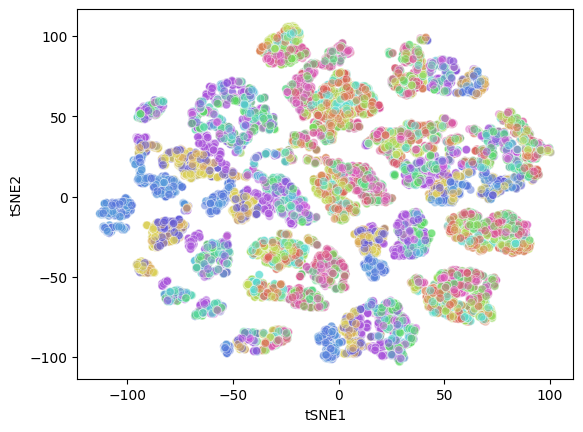

In [214]:
_ = sns.scatterplot(
    data=repr_df,
    x="tSNE1", y="tSNE2",
    hue="alphabet",
    palette=sns.color_palette("hls", len(repr_df.alphabet.unique())),
    alpha=0.5,
    legend=None
)
#_ = plt.legend(title="transformation type", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

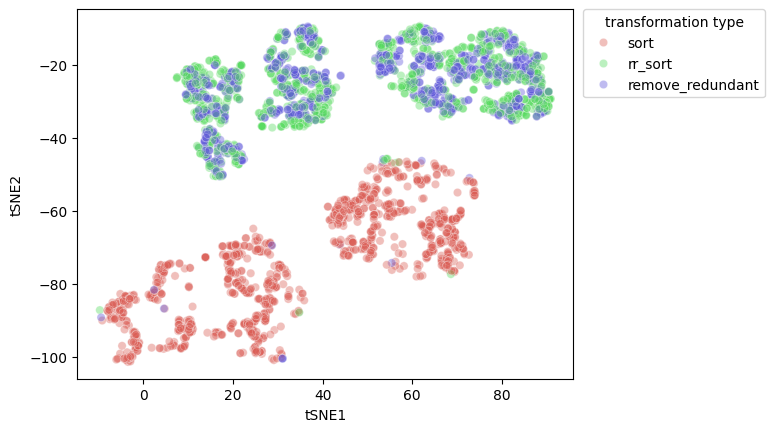

In [203]:
_ = sns.scatterplot(
    data=repr_df[repr_df["transformation"].isin(["remove_redundant","rr_sort","sort"])],
    x="tSNE1", y="tSNE2",
    hue="transformation",
    palette=sns.color_palette("hls", 3),
    legend="full",
    alpha=0.4
)
_ = plt.legend(title="transformation type", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)


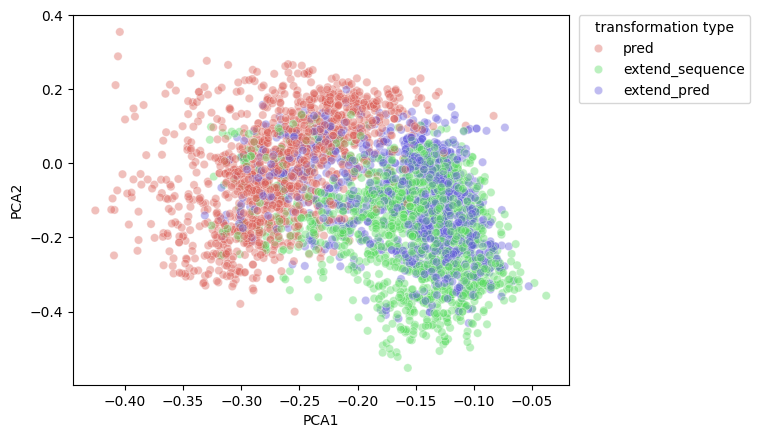

In [196]:
_ = sns.scatterplot(
    data=repr_df[repr_df["transformation"].isin(["extend_sequence","pred","extend_pred"])],
    x="PCA1", y="PCA2",
    hue="transformation",
    palette=sns.color_palette("hls", 3),
    legend="full",
    alpha=0.4
)
_ = plt.legend(title="transformation type", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)